In [1]:
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from datetime import datetime
import pandas as pd
%matplotlib widget

In [118]:
plt.style.use('dark_background')
#plt.style.use('default')

In [119]:
def get_stock_data(ticker='intc', start='1998-01-01', end='2002-12-31'):
    data = yf.download(ticker, start=start, end=end).reset_index()
    df = pd.DataFrame(data)
    df['year'] = df.Date.map(lambda x: str(x).split('-')[0])
    df['month'] = df.Date.map(lambda x: str(x).split('-')[1])
    df['day'] = df.Date.map(lambda x: str(x).split('-')[2].split(' ')[0])
    df.columns = [col[0] for col in df.columns]
    return df


def get_prev_xday_high(df, num_days=30):
    prev_xday_high = np.array([df['Close'][x-num_days:x].max().item() for x in range(len(df))[num_days:]])
    df = df[num_days:].reset_index(drop=True)
    df[f'prev_{num_days}_high'] = prev_xday_high
    df[f'pct_change'] = (df['Close'].values.flatten() - prev_xday_high) / prev_xday_high * 100
    return df

In [56]:
# msft_df = get_stock_data('msft', end='2025-11-5');
# intc_df = get_stock_data('intc', end='2025-11-5');
# meta_df = get_stock_data('meta', end='2025-11-5');
# nvidia_df = get_stock_data('nvda', end='2025-11-5');
# amd_df = get_stock_data('nvda', end='2025-11-5');
# plantir_df = get_stock_data('pltr', end='2025-11-5');
# oracle_df = get_stock_data('orcl', end='2025-11-5');
# amd_df = get_stock_data('amd', end='2025-11-5');
# amazon_df = get_stock_data('amzn', end='2025-11-5');
# google_df = get_stock_data('googl', end='2025-11-5');

msft_df.shape, google_df.shape, plantir_df.shape, nvidia_df.shape, meta_df.shape

((7004, 9), (5338, 9), (1281, 9), (6739, 9), (3386, 9))

In [120]:
def get_prev_xday_high(df, num_days=30):
    prev_xday_high = np.array([df['Close'][x-num_days:x].max().item() for x in range(len(df))[num_days:]])
    df = df[num_days:].reset_index(drop=True)
    df[f'prev_{num_days}_high'] = prev_xday_high
    df[f'pct_change'] = (df['Close'].values.flatten() - prev_xday_high) / prev_xday_high * 100
    return df

In [121]:
# msft_final = get_prev_xday_high(msft_df)
# intc_final = get_prev_xday_high(intc_df)
# meta_final = get_prev_xday_high(meta_df)
# nvidia_final = get_prev_xday_high(nvidia_df)
# plantir_final = get_prev_xday_high(plantir_df)

In [122]:
# mstr_df = get_prev_xday_high(get_stock_data('mstr', end='2025-11-6' ));
# eth_df = get_prev_xday_high(get_stock_data('eth', end='2025-11-6' ));
btc_df = get_prev_xday_high(get_stock_data('btc', start='2020-01-01', end='2025-11-6' ));
mstr_df.shape, btc_df.shape, eth_df.shape

/tmp/ipykernel_225116/1348073739.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


((6865, 11), (289, 11), (295, 11))

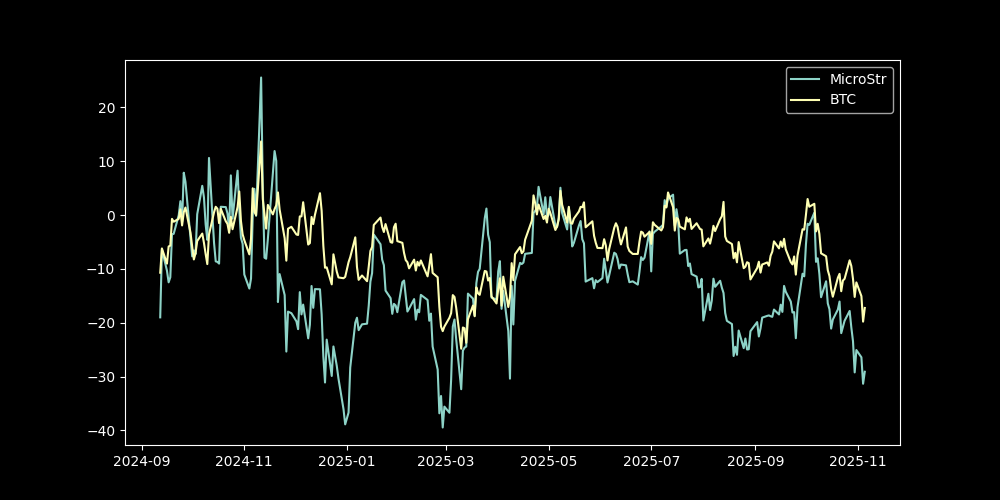

In [123]:
plt.figure(figsize=(10, 5))
plt.plot(mstr_df.Date[-289:], mstr_df['pct_change'][-289:], label="MicroStr")
plt.plot(btc_df.Date, btc_df['pct_change'], label="BTC")  
plt.legend()

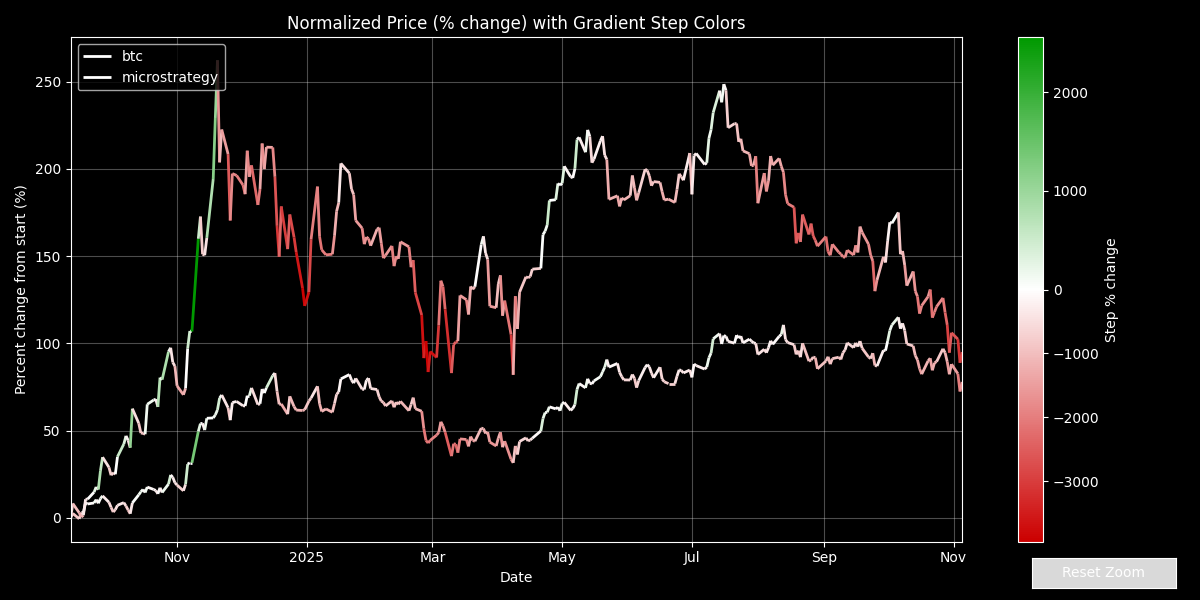

In [125]:
plot_stock_with_gradient_colors(
    [btc_df, mstr_df[-289:]],
    labels=['btc', 'microstrategy']
)

In [114]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import SpanSelector, Button
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import numpy as np
import pandas as pd

def plot_stock_with_gradient_colors(
    data,
    labels=None,             # <- NEW: labels for legend, e.g. ["MSFT", "NVDA", ...]
    title=None,
    enable_interaction=True,
    min_span_days=3,         # don't allow zoom-in narrower than this
    max_out_pad=0.05,        # allow at most ±5% beyond data range when zooming out
):
    # --------- 1. Normalize input to list of DataFrames ----------
    if isinstance(data, (list, tuple)):
        dfs = [d.copy() for d in data]
    else:
        dfs = [data.copy()]

    n_series = len(dfs)

    # Default labels if not provided
    if labels is None:
        labels = [f"Series {i+1}" for i in range(n_series)]
    elif len(labels) != n_series:
        raise ValueError("labels must have the same length as data (number of series)")

    series = []        # will hold dicts with x, y (percent), segs, pct_step, label
    all_pct_step = []  # for global color normalization
    all_x = []
    all_y = []

    for df, label in zip(dfs, labels):
        df['Date'] = pd.to_datetime(df['Date'])
        x = mdates.date2num(df['Date'].to_numpy())

        price = df['Close'].to_numpy(dtype=float).reshape(-1)
        if price.size < 2:
            # skip degenerate series
            continue

        # --------- y-axis: percent change from first value ----------
        base = price[0]
        y_pct = (price / base - 1.0) * 100.0  # e.g. 0% at start, +10, -5, etc.

        # --------- Colors: step-wise percent change ----------
        if 'pct_change' in df.columns:
            pc = np.asarray(df['pct_change'], dtype=float)
            if len(pc) == len(price):
                pc_step = pc[1:]
            else:
                pc_step = pc[:len(price) - 1]
            pc_step *= 100.0  # convert to % units for colorbar
        else:
            pc_step = df['Close'].pct_change().to_numpy()[1:] * 100.0

        # Segments for this series (in y-percent space)
        points = np.column_stack([x, y_pct]).reshape(-1, 1, 2)
        segs = np.concatenate([points[:-1], points[1:]], axis=1)

        series.append(
            dict(
                x=x,
                y=y_pct,
                segs=segs,
                pct_step=pc_step,
                label=label,
            )
        )

        all_pct_step.append(pc_step)
        all_x.append(x)
        all_y.append(y_pct)

    if not series:
        raise ValueError("No valid time series to plot (check your data).")

    all_pct_step = np.concatenate(all_pct_step)
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)

    # --------- 2. Colormap / normalization shared across series ----------
    colors_dict = {
        'red':   [(0.0, 0.8, 0.8), (0.5, 1.0, 1.0), (1.0, 0.0, 0.0)],
        'green': [(0.0, 0.0, 0.0), (0.5, 1.0, 1.0), (1.0, 0.6, 0.6)],
        'blue':  [(0.0, 0.0, 0.0), (0.5, 1.0, 1.0), (1.0, 0.0, 0.0)],
    }
    custom_cmap = LinearSegmentedColormap('RedGreen', colors_dict)
    norm = TwoSlopeNorm(
        vmin=np.nanmin(all_pct_step),
        vcenter=0.0,
        vmax=np.nanmax(all_pct_step),
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    # --------- 3. Add a LineCollection per series ----------
    for s in series:
        lc = LineCollection(
            s['segs'],
            cmap=custom_cmap,
            norm=norm,
            linewidth=2,
        )
        lc.set_array(s['pct_step'])
        lc.set_label(s['label'])   # <- label used by legend
        ax.add_collection(lc)

    # Shared colorbar
    fig.colorbar(lc, ax=ax, label='Step % change')

    # Initial limits: union over all series
    DATA_LEFT, DATA_RIGHT = np.nanmin(all_x), np.nanmax(all_x)
    ymin, ymax = np.nanmin(all_y), np.nanmax(all_y)
    ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

    ax.set_xlim(DATA_LEFT, DATA_RIGHT)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    # Adaptive date ticks
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel('Date')

    # --------- y-axis now shows percent change ----------
    ax.set_ylabel('Percent change from start (%)')
    ax.set_title(title or 'Normalized Price (% change) with Gradient Step Colors')
    ax.grid(True, alpha=0.3)

    # Legend so you know which line is which
    ax.legend(loc='upper left')

    fig.tight_layout()

    if not enable_interaction:
        plt.show()
        return

    # ---------- 4. BOUNDS & CLAMPING (global x-range) ----------
    DATA_SPAN = max(DATA_RIGHT - DATA_LEFT, 1e-9)
    MIN_SPAN = max(min_span_days, 1e-6)           # days, minimum zoom-in width
    MAX_SPAN = DATA_SPAN * (1 + 2*max_out_pad)    # max zoom-out width
    BOUND_LEFT = DATA_LEFT - DATA_SPAN * max_out_pad
    BOUND_RIGHT = DATA_RIGHT + DATA_SPAN * max_out_pad

    def clamp_xlim(left, right, anchor=None):
        # Normalize order
        if right < left:
            left, right = right, left
        span = right - left

        # Enforce min/max span
        span = min(max(span, MIN_SPAN), MAX_SPAN)

        # Choose anchor (cursor for scroll; center otherwise)
        c = anchor if anchor is not None else 0.5*(left + right)
        left = c - span/2
        right = c + span/2

        # Enforce hard bounds
        if left < BOUND_LEFT:
            left = BOUND_LEFT
            right = left + span
        if right > BOUND_RIGHT:
            right = BOUND_RIGHT
            left = right - span

        return left, right

    def _update_ylim(xmin, xmax):
        # Compute y-limits over *all* series within current x-window
        lows, highs = [], []
        for s in series:
            x = s['x']
            y = s['y']
            mask = (x >= xmin) & (x <= xmax)
            if np.any(mask):
                yy = y[mask]
                lows.append(np.nanmin(yy))
                highs.append(np.nanmax(yy))
        if not lows:
            return
        lo, hi = np.nanmin(lows), np.nanmax(highs)
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.set_ylim(lo - pad, hi + pad)

    orig_xlim = clamp_xlim(DATA_LEFT, DATA_RIGHT)
    orig_ylim = ax.get_ylim()

    # ---------- 5. Drag-to-zoom ----------
    def onselect(xmin, xmax):
        left, right = clamp_xlim(xmin, xmax)
        ax.set_xlim(left, right)
        _update_ylim(left, right)
        fig.canvas.draw_idle()

    try:
        span = SpanSelector(
            ax, onselect, direction='horizontal',
            useblit=False, interactive=True, props=dict(alpha=0.2)
        )
    except TypeError:  # older Matplotlib
        span = SpanSelector(
            ax, onselect, direction='horizontal',
            useblit=False, interactive=True, rectprops=dict(alpha=0.2)
        )

    # ---------- 6. Scroll zoom (clamped) ----------
    def on_scroll(event):
        if event.inaxes is not ax or event.xdata is None:
            return
        cur_left, cur_right = ax.get_xlim()
        x0 = event.xdata
        zoom_in = (getattr(event, 'step', 0) > 0) or (getattr(event, 'button', None) == 'up')
        scale = 1.2 if zoom_in else (1/1.2)
        left = x0 - (x0 - cur_left) / scale
        right = x0 + (cur_right - x0) / scale
        left, right = clamp_xlim(left, right, anchor=x0)
        ax.set_xlim(left, right)
        _update_ylim(left, right)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect('scroll_event', on_scroll)

    # ---------- 7. Reset button ----------
    reset_ax = fig.add_axes([0.86, 0.02, 0.12, 0.05])
    reset_btn = Button(reset_ax, 'Reset Zoom')

    def on_reset(_):
        ax.set_xlim(*orig_xlim)
        ax.set_ylim(*orig_ylim)
        fig.canvas.draw_idle()

    reset_btn.on_clicked(on_reset)

    plt.show()

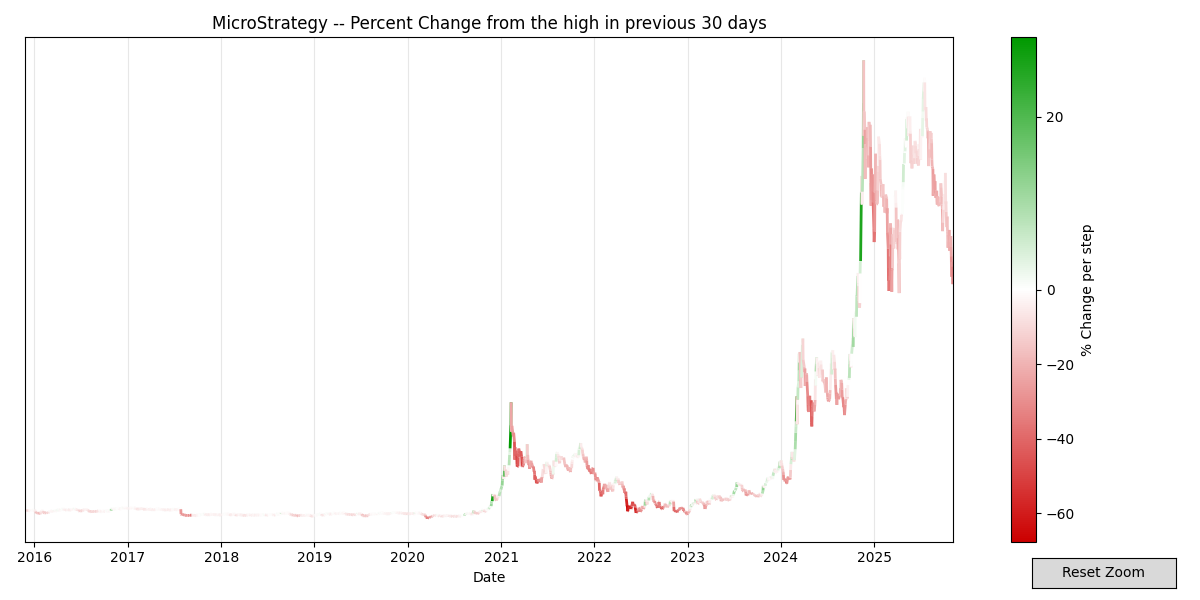

In [113]:
plot_stock_with_gradient_colors(mstr_df[-2500:], title="MicroStrategy -- Percent Change from the high in previous 30 days");

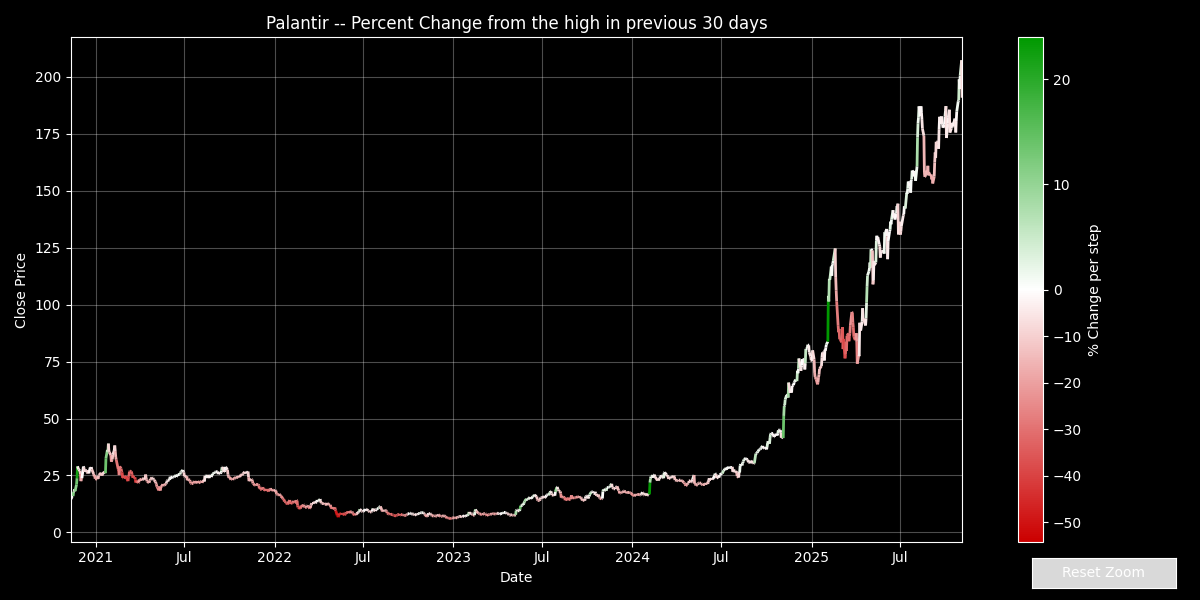

In [60]:
plot_stock_with_gradient_colors(plantir_final[-2500:], title="Palantir -- Percent Change from the high in previous 30 days");

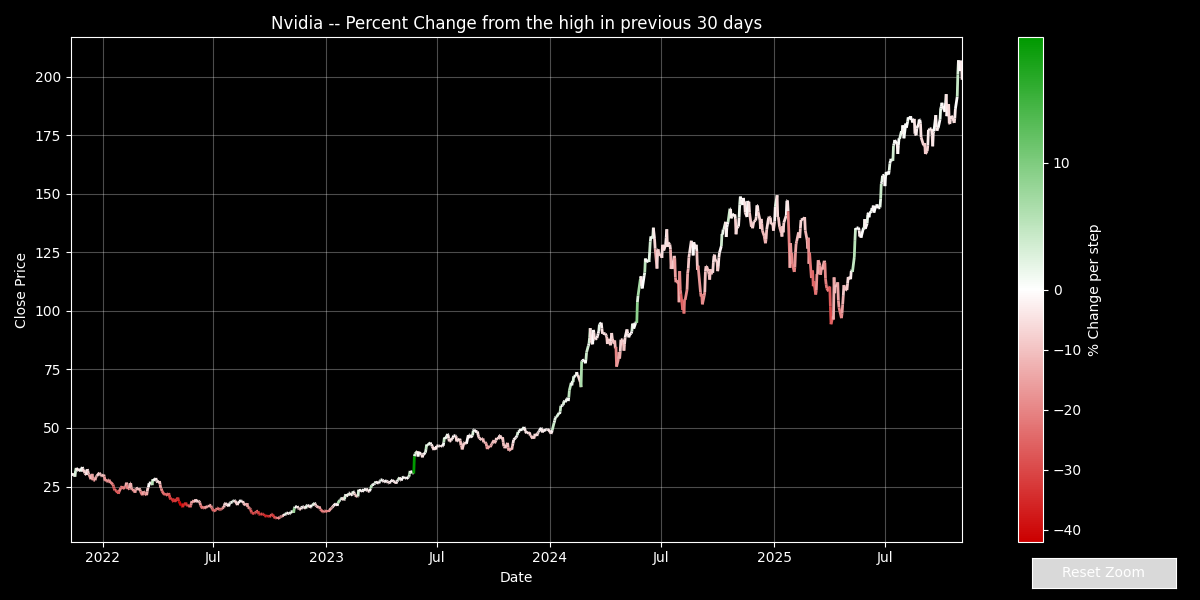

In [61]:
plot_stock_with_gradient_colors(nvidia_final[-1000:], title="Nvidia -- Percent Change from the high in previous 30 days");

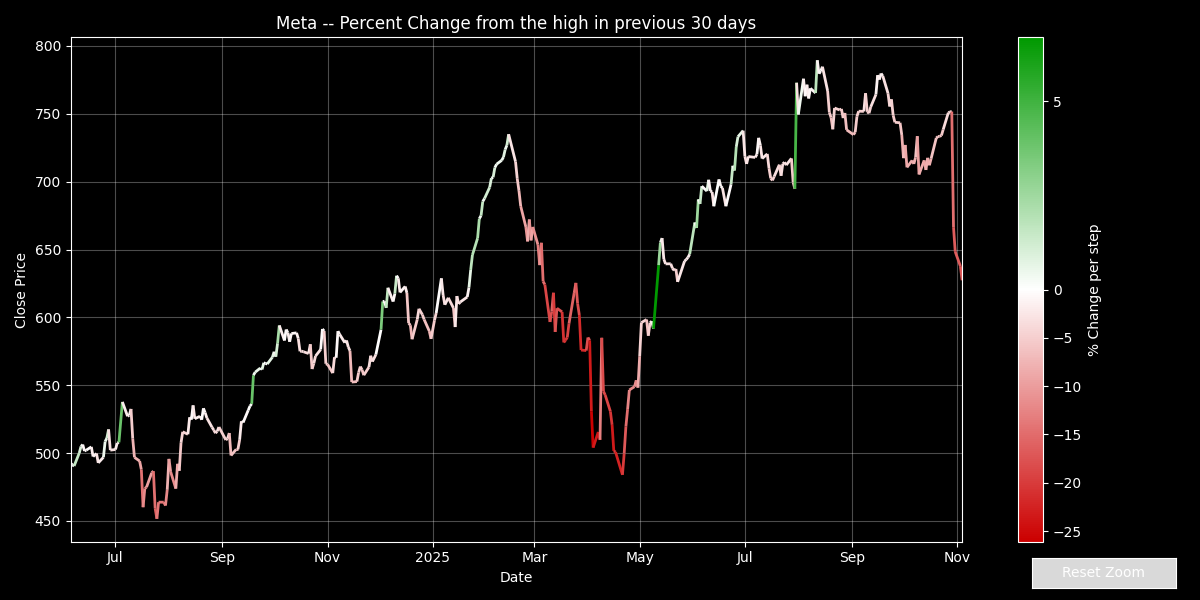

In [101]:
plot_stock_with_gradient_colors(meta_final[3000:], title="Meta -- Percent Change from the high in previous 30 days");

In [54]:
#plot_stock_with_gradient_colors(meta_final)

In [100]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import SpanSelector, Button
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import numpy as np
import pandas as pd

def plot_stock_with_gradient_colors(
    df,
    title=None,
    enable_interaction=True,
    min_span_days=3,          # don't allow zoom-in narrower than this
    max_out_pad=0.05,          # allow at most ±5% beyond data range when zooming out
):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    x = mdates.date2num(df['Date'].to_numpy())
    y = df['Close'].to_numpy().reshape(-1)

    # Ensure N-1 pct values for N points (segments)
    if 'pct_change' in df.columns:
        pc = np.asarray(df['pct_change'])
        pct_values = pc[1:] if len(pc) == len(y) else pc[:len(y)-1]
    else:
        pct_values = df['Close'].pct_change().to_numpy()[1:]

    # Segments
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Diverging cmap centered at 0
    colors_dict = {
        'red':   [(0.0, 0.8, 0.8), (0.5, 1.0, 1.0), (1.0, 0.0, 0.0)],
        'green': [(0.0, 0.0, 0.0), (0.5, 1.0, 1.0), (1.0, 0.6, 0.6)],
        'blue':  [(0.0, 0.0, 0.0), (0.5, 1.0, 1.0), (1.0, 0.0, 0.0)],
    }
    custom_cmap = LinearSegmentedColormap('RedGreen', colors_dict)
    norm = TwoSlopeNorm(vmin=np.nanmin(pct_values), vcenter=0.0, vmax=np.nanmax(pct_values))

    fig, ax = plt.subplots(figsize=(12, 6))
    lc = LineCollection(segments, cmap=custom_cmap, norm=norm, linewidth=2)
    lc.set_array(pct_values)
    ax.add_collection(lc)
    fig.colorbar(lc, ax=ax, label='% Change per step')

    # Initial limits
    ax.set_xlim(x.min(), x.max())
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    # Adaptive date ticks
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel('Date'); ax.set_ylabel('Close Price')
    ax.set_title(title or 'Stock Price with Gradient Color-Coded Changes')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if not enable_interaction:
        plt.show(); return

    # ---------- BOUNDS & CLAMPING ----------
    DATA_LEFT, DATA_RIGHT = x.min(), x.max()
    DATA_SPAN = max(DATA_RIGHT - DATA_LEFT, 1e-9)  # protect from zero
    MIN_SPAN = max(min_span_days, 1e-6)            # days, minimum zoom-in width
    MAX_SPAN = DATA_SPAN * (1 + 2*max_out_pad)     # max zoom-out width
    BOUND_LEFT = DATA_LEFT - DATA_SPAN * max_out_pad
    BOUND_RIGHT = DATA_RIGHT + DATA_SPAN * max_out_pad

    def clamp_xlim(left, right, anchor=None):
        # Normalize order
        if right < left:
            left, right = right, left
        span = right - left

        # Enforce min/max span
        span = min(max(span, MIN_SPAN), MAX_SPAN)

        # Choose anchor (cursor for scroll; center otherwise)
        c = anchor if anchor is not None else 0.5*(left + right)
        left = c - span/2
        right = c + span/2

        # Enforce hard bounds
        if left < BOUND_LEFT:
            left = BOUND_LEFT
            right = left + span
        if right > BOUND_RIGHT:
            right = BOUND_RIGHT
            left = right - span

        return left, right

    def _update_ylim(xmin, xmax):
        mask = (x >= xmin) & (x <= xmax)
        if not np.any(mask): return
        ywin = y[mask]
        lo, hi = np.nanmin(ywin), np.nanmax(ywin)
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.set_ylim(lo - pad, hi + pad)

    orig_xlim = clamp_xlim(*ax.get_xlim())  # store clamped
    orig_ylim = ax.get_ylim()

    # Drag-to-zoom
    def onselect(xmin, xmax):
        left, right = clamp_xlim(xmin, xmax)
        ax.set_xlim(left, right); _update_ylim(left, right); fig.canvas.draw_idle()

    try:
        span = SpanSelector(ax, onselect, direction='horizontal',
                            useblit=False, interactive=True, props=dict(alpha=0.2))
    except TypeError:
        span = SpanSelector(ax, onselect, direction='horizontal',
                            useblit=False, interactive=True, rectprops=dict(alpha=0.2))

    # Scroll zoom (clamped)
    def on_scroll(event):
        if event.inaxes is not ax or event.xdata is None: return
        cur_left, cur_right = ax.get_xlim()
        x0 = event.xdata
        zoom_in = (getattr(event, 'step', 0) > 0) or (getattr(event, 'button', None) == 'up')
        scale = 1.2 if zoom_in else (1/1.2)
        left = x0 - (x0 - cur_left) / scale
        right = x0 + (cur_right - x0) / scale
        left, right = clamp_xlim(left, right, anchor=x0)
        ax.set_xlim(left, right); _update_ylim(left, right); fig.canvas.draw_idle()

    fig.canvas.mpl_connect('scroll_event', on_scroll)

    # Reset button
    reset_ax = fig.add_axes([0.86, 0.02, 0.12, 0.05])
    reset_btn = Button(reset_ax, 'Reset Zoom')
    def on_reset(_):
        ax.set_xlim(*orig_xlim); ax.set_ylim(*orig_ylim); fig.canvas.draw_idle()
    reset_btn.on_clicked(on_reset)

    import plotly.express as px
    fig = px.line(df, x="Date", y="Close", title="Price")
    fig.write_html("plot.html", include_plotlyjs="cdn")


    plt.show()

In [51]:
# plot_stock_with_gradient_colors(meta_final[2000:].reset_index(drop=True), 
#                                'Meta Price with color showing % change from the high of past 30 days')

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import numpy as np
import pandas as pd

def plot_stock_with_gradient_colors(df, title=None):
    # Convert Date column to datetime if not already
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Prepare the data
    x = mdates.date2num(df['Date'])
    y = df['Close'].values.flatten()
    
    # Create segments for LineCollection
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Create custom diverging colormap: red (negative) -> white (zero) -> green (positive)
    colors_dict = {
        'red':   [(0.0, 0.8, 0.8),   # dark red at minimum
                  (0.5, 1.0, 1.0),   # white at center (zero)
                  (1.0, 0.0, 0.0)],  # no red at maximum
        'green': [(0.0, 0.0, 0.0),   # no green at minimum
                  (0.5, 1.0, 1.0),   # white at center (zero)
                  (1.0, 0.6, 0.6)],  # dark green at maximum
        'blue':  [(0.0, 0.0, 0.0),   # no blue at minimum
                  (0.5, 1.0, 1.0),   # white at center (zero)
                  (1.0, 0.0, 0.0)]   # no blue at maximum
    }
    custom_cmap = LinearSegmentedColormap('RedGreen', colors_dict)
    
    # Normalize colors around zero (center point)
    pct_values = df['pct_change'].values[:-1]  # One less than points (for segments)
    norm = TwoSlopeNorm(vmin=pct_values.min(), vcenter=0, vmax=pct_values.max())
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create LineCollection with colormap
    lc = LineCollection(segments, cmap=custom_cmap, norm=norm, linewidth=2)
    lc.set_array(pct_values)  # Map pct_change to colors
    ax.add_collection(lc)
    
    # Add colorbar to show the scale
    cbar = fig.colorbar(lc, ax=ax, label='% Change')
    
    # Set axis limits
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min() * 0.95, y.max() * 1.05)
    
    # Format x-axis with dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    
    # Labels and title
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    if title is None:
        ax.set_title('Stock Price with Gradient Color-Coded Changes')
    else:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

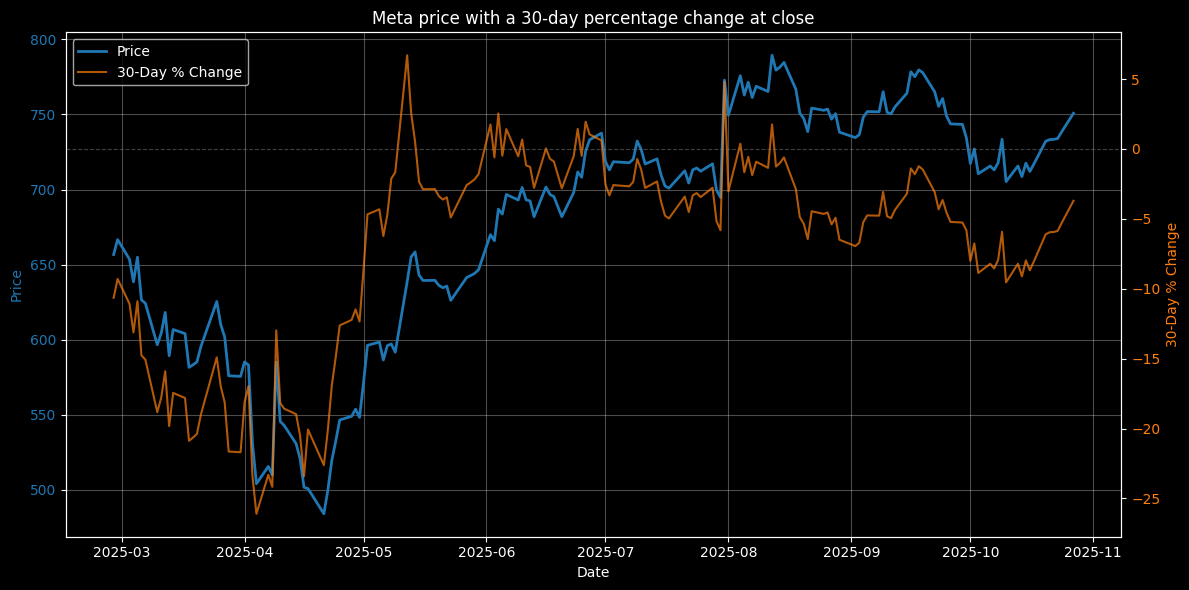

In [16]:
plot_price_with_pct_change(meta_final[-len(meta_final)//20:], 'Date', 'Close', periods=30,
                           title='Meta price with a 30-day percentage change at close');

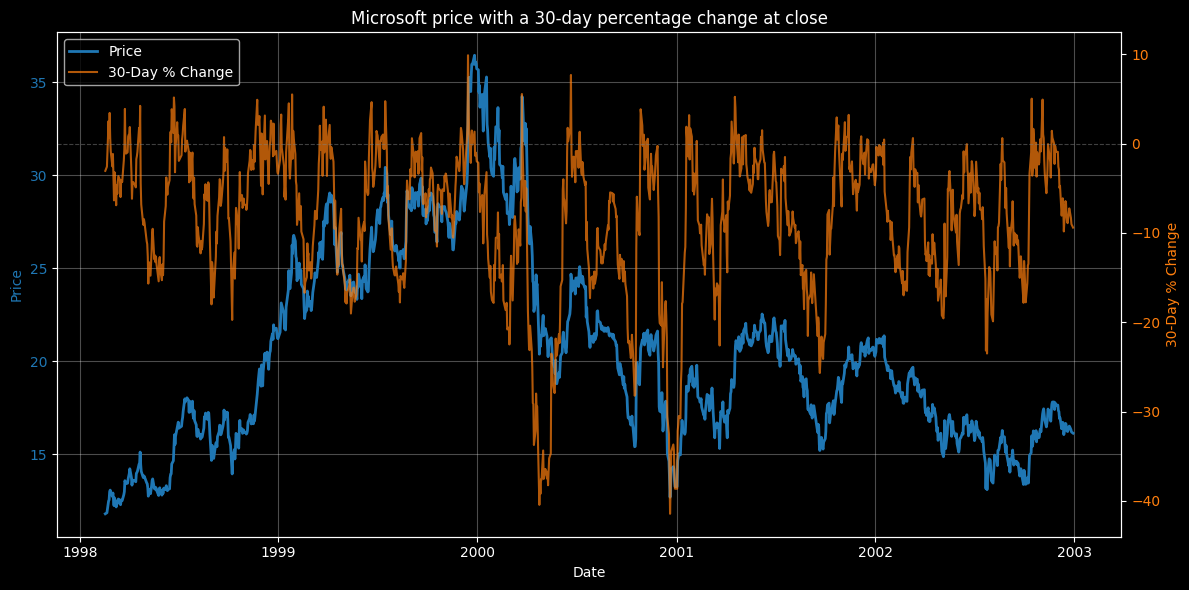

In [172]:
plot_price_with_pct_change(msft_final, 'Date', 'Close', periods=30,
                           title='Microsoft price with a 30-day percentage change at close');

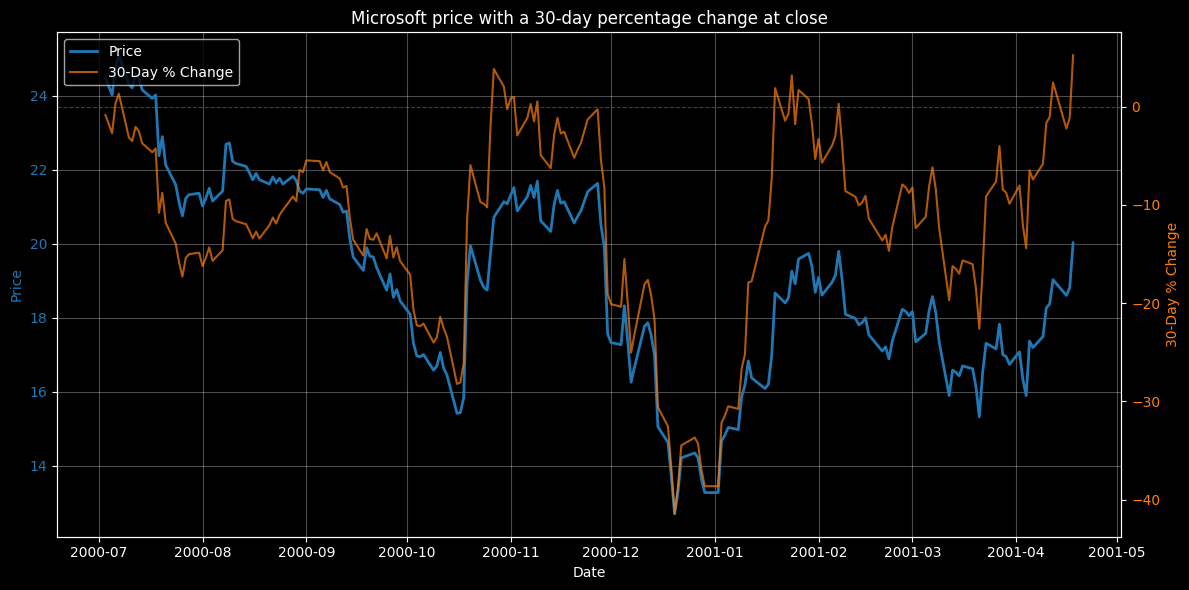

In [171]:
plot_price_with_pct_change(msft_final[600:800], 'Date', 'Close', periods=30,
                           title='Microsoft price with a 30-day percentage change at close');

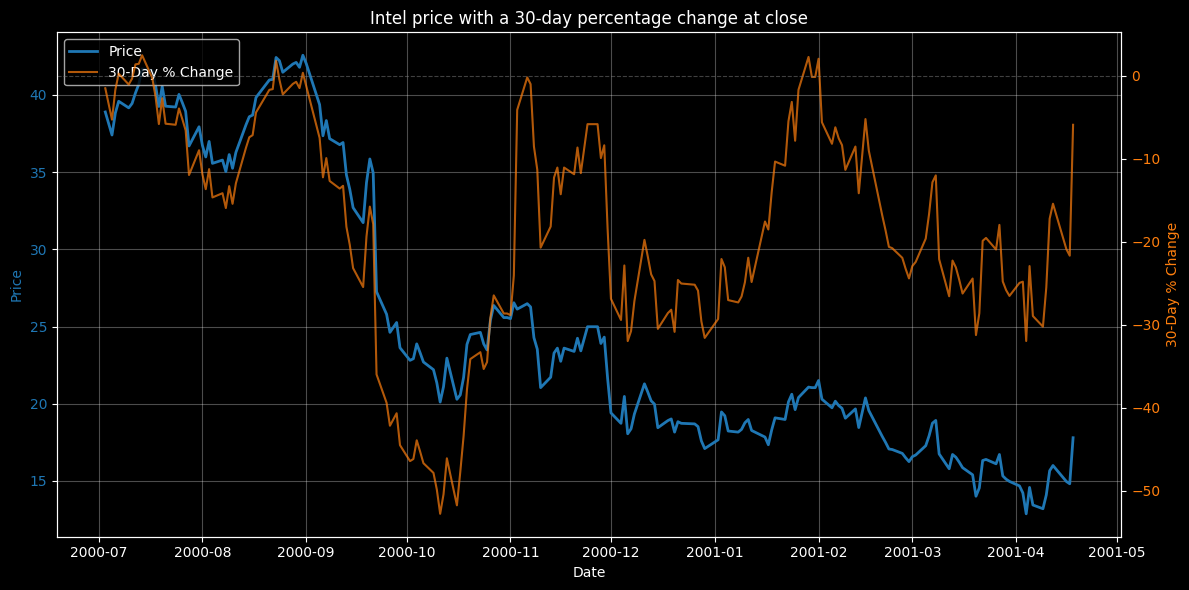

In [170]:
plot_price_with_pct_change(intc_final[600:800], 'Date', 'Close', periods=30,
                           title='Intel price with a 30-day percentage change at close');

In [10]:
def plot_price_with_pct_change(df, date_col, price_col, periods=30, figsize=(12, 6), title=None):
    """
    Plot time series price data with percentage change overlay.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing your time series data
    date_col : str
        Name of the column containing dates
    price_col : str
        Name of the column containing prices
    periods : int, optional (default=30)
        Number of periods for percentage change calculation
    figsize : tuple, optional (default=(12, 6))
        Figure size as (width, height)
    
    Returns:
    --------
    fig, (ax1, ax2) : matplotlib figure and axes objects
    """
    
    # Create a copy and set date as index
    df_plot = df.copy()
    df_plot[date_col] = pd.to_datetime(df_plot[date_col])
    df_plot = df_plot.set_index(date_col)
    
    # Calculate percentage change
    #df_plot['pct_change'] = df_plot[price_col].pct_change(periods=periods) * 100
    
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot price on primary axis
    color1 = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price', color=color1)
    ax1.plot(df_plot.index, df_plot[price_col], color=color1, 
             linewidth=2, label='Price')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    
    # Create secondary axis
    ax2 = ax1.twinx()
    # Plot percentage change on secondary axis
    color2 = 'tab:orange'
    ax2.set_ylabel(f'{periods}-Day % Change', color=color2)
    ax2.plot(df_plot.index, df_plot['pct_change'], color=color2, 
             linewidth=1.5, alpha=0.7, label=f'{periods}-Day % Change')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    if title:
        plt.title(title)
    else:
        plt.title(f'{price_col} with {periods}-Day Percentage Change')
    fig.tight_layout()
    
    return fig, (ax1, ax2)